## Business Objective

### Importing the libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('EV Charging Behavior Dataset.csv')

In [3]:
df

,User_ID,Age,City_Tier,EV_Type,Battery_Capacity_kWh,Charging_Sessions_Per_Month,Avg_Charge_Cost,Distance_Travelled_Per_Month,Income_Level,Loan_Taken,Missed_Payments_Last_6M,Tenure_Months,Charging_Location_Type,App_Usage_Score,Charger_Working_Status,Charging_Time_Minutes,High_Default_Risk,Charging_Efficiency_Index
0,1,59,Tier3,5KW,40.7,19,325.10,1702,Low,0,2,1,Public,1,Working,58.5,0,100.00
1,2,49,Tier5,5KW,31.7,9,439.97,2377,High,0,0,1,Highway,7,Working,47.0,0,96.36
2,3,35,Tier5,5KW,36.8,24,309.80,1905,Low,0,5,6,Highway,4,Working,53.5,1,100.00
3,4,63,Tier5,2KW,38.5,32,353.90,2074,Medium,0,1,31,Highway,1,Not Working,112.0,1,57.96
4,5,28,Tier1,5KW,33.2,8,597.43,1212,Medium,0,2,24,Private,6,Working,58.0,0,84.56
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18941,18942,54,Tier5,2KW,38.0,23,420.80,938,High,0,0,16,Highway,8,Working,58.0,0,100.00
18942,18943,47,Tier3,5KW,28.6,29,555.51,1289,High,1,1,28,Highway,1,Working,39.8,1,100.00
18943,18944,59,Tier2,5KW,28.6,17,500.97,577,Medium,0,5,15,Private,3,Working,34.3,0,100.00
18944,18945,64,Tier2,4KW,42.3,30,417.63,2255,Low,0,1,18,Highway,2,Working,65.3,1,100.00


###  Data Understanding And Basic EDA Checks

In [4]:
df.head()

,User_ID,Age,City_Tier,EV_Type,Battery_Capacity_kWh,Charging_Sessions_Per_Month,Avg_Charge_Cost,Distance_Travelled_Per_Month,Income_Level,Loan_Taken,Missed_Payments_Last_6M,Tenure_Months,Charging_Location_Type,App_Usage_Score,Charger_Working_Status,Charging_Time_Minutes,High_Default_Risk,Charging_Efficiency_Index
0,1,59,Tier3,5KW,40.7,19,325.10,1702,Low,0,2,1,Public,1,Working,58.5,0,100.00
1,2,49,Tier5,5KW,31.7,9,439.97,2377,High,0,0,1,Highway,7,Working,47.0,0,96.36
2,3,35,Tier5,5KW,36.8,24,309.80,1905,Low,0,5,6,Highway,4,Working,53.5,1,100.00
3,4,63,Tier5,2KW,38.5,32,353.90,2074,Medium,0,1,31,Highway,1,Not Working,112.0,1,57.96
4,5,28,Tier1,5KW,33.2,8,597.43,1212,Medium,0,2,24,Private,6,Working,58.0,0,84.56


In [5]:
df.shape

(18946, 18)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 18946 entries, 0 to 18945
Data columns (total 18 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   User_ID                       18946 non-null  int64  
 1   Age                           18946 non-null  int64  
 2   City_Tier                     18946 non-null  str    
 3   EV_Type                       18946 non-null  str    
 4   Battery_Capacity_kWh          18946 non-null  float64
 5   Charging_Sessions_Per_Month   18946 non-null  int64  
 6   Avg_Charge_Cost               18946 non-null  float64
 7   Distance_Travelled_Per_Month  18946 non-null  int64  
 8   Income_Level                  18946 non-null  str    
 9   Loan_Taken                    18946 non-null  int64  
 10  Missed_Payments_Last_6M       18946 non-null  int64  
 11  Tenure_Months                 18946 non-null  int64  
 12  Charging_Location_Type        18946 non-null  str    
 13  App_Usage_Sc

In [7]:
df.describe()

,User_ID,Age,Battery_Capacity_kWh,Charging_Sessions_Per_Month,Avg_Charge_Cost,Distance_Travelled_Per_Month,Loan_Taken,Missed_Payments_Last_6M,Tenure_Months,App_Usage_Score,Charging_Time_Minutes,High_Default_Risk,Charging_Efficiency_Index
count,18946.000000,18946.000000,18946.000000,18946.000000,18946.000000,18946.000000,18946.000000,18946.000000,18946.000000,18946.000000,18946.000000,18946.000000,18946.000000
mean,9473.500000,42.919930,35.027890,19.496358,450.124728,1399.960044,0.408266,2.489866,24.096749,5.510767,62.940257,0.443999,87.653957
std,5469.383436,12.915867,10.047099,8.656905,120.149182,635.388130,0.491526,1.701978,13.583756,2.870352,32.274571,0.496867,25.041681
min,1.000000,21.000000,-8.000000,5.000000,-85.560000,300.000000,0.000000,0.000000,1.000000,1.000000,-14.100000,0.000000,0.000000
25%,4737.250000,32.000000,28.300000,12.000000,370.190000,848.250000,0.000000,1.000000,12.000000,3.000000,43.100000,0.000000,90.360000
50%,9473.500000,43.000000,35.100000,19.000000,449.640000,1399.500000,0.000000,2.000000,24.000000,6.000000,55.600000,0.000000,100.000000
75%,14209.750000,54.000000,41.900000,27.000000,530.467500,1951.000000,1.000000,4.000000,36.000000,8.000000,71.000000,1.000000,100.000000
max,18946.000000,65.000000,72.500000,34.000000,901.220000,2499.000000,1.000000,5.000000,47.000000,10.000000,278.200000,1.000000,100.000000


### Checking the Null'S and Duplicates

In [8]:
df.isnull().sum()

User_ID                         0
Age                             0
City_Tier                       0
EV_Type                         0
Battery_Capacity_kWh            0
Charging_Sessions_Per_Month     0
Avg_Charge_Cost                 0
Distance_Travelled_Per_Month    0
Income_Level                    0
Loan_Taken                      0
Missed_Payments_Last_6M         0
Tenure_Months                   0
Charging_Location_Type          0
App_Usage_Score                 0
Charger_Working_Status          0
Charging_Time_Minutes           0
High_Default_Risk               0
Charging_Efficiency_Index       0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

### Convert the String to object 

In [10]:
cat_cols=df.select_dtypes(include='str').columns

for i in cat_cols:
    df[i] = df[i].astype(object)

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 18946 entries, 0 to 18945
Data columns (total 18 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   User_ID                       18946 non-null  int64  
 1   Age                           18946 non-null  int64  
 2   City_Tier                     18946 non-null  object 
 3   EV_Type                       18946 non-null  object 
 4   Battery_Capacity_kWh          18946 non-null  float64
 5   Charging_Sessions_Per_Month   18946 non-null  int64  
 6   Avg_Charge_Cost               18946 non-null  float64
 7   Distance_Travelled_Per_Month  18946 non-null  int64  
 8   Income_Level                  18946 non-null  object 
 9   Loan_Taken                    18946 non-null  int64  
 10  Missed_Payments_Last_6M       18946 non-null  int64  
 11  Tenure_Months                 18946 non-null  int64  
 12  Charging_Location_Type        18946 non-null  object 
 13  App_Usage_Sc

### Visualization

## Univariate Analysis

<Axes: xlabel='Age', ylabel='Count'>

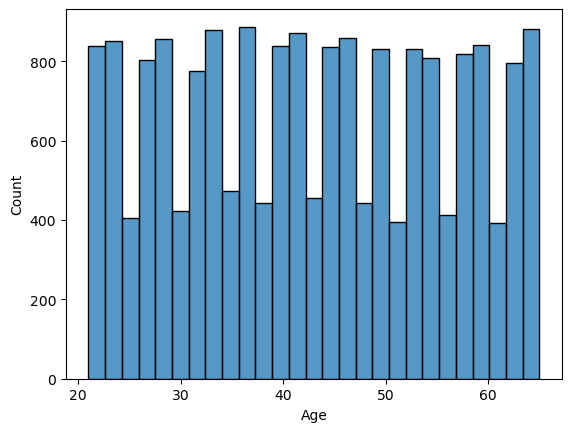

In [12]:
sns.histplot(data=df,x=df['Age'])

<Axes: xlabel='Tenure_Months', ylabel='Count'>

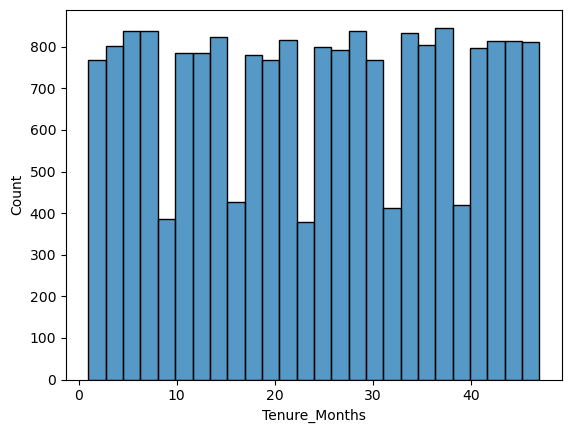

In [13]:
sns.histplot(data=df,x=df['Tenure_Months'])

<Axes: xlabel='Distance_Travelled_Per_Month', ylabel='Count'>

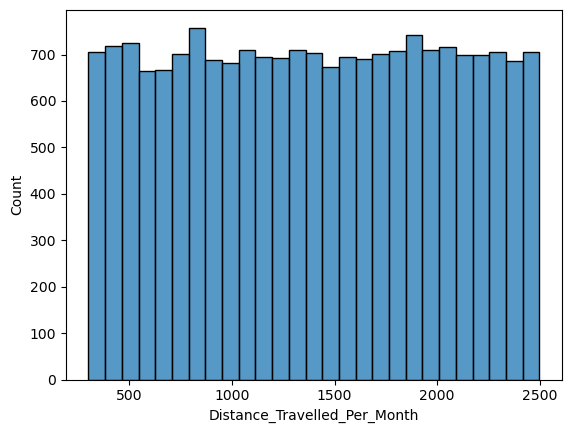

In [14]:
sns.histplot(data=df,x=df['Distance_Travelled_Per_Month'])

<Axes: xlabel='Charging_Time_Minutes', ylabel='Count'>

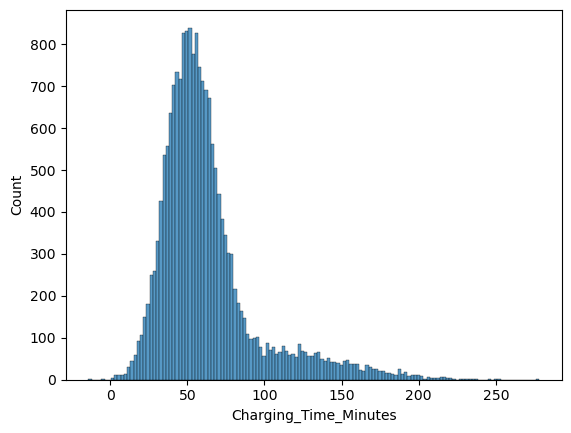

In [15]:
sns.histplot(data=df,x=df['Charging_Time_Minutes'])

<Axes: xlabel='Charger_Working_Status', ylabel='count'>

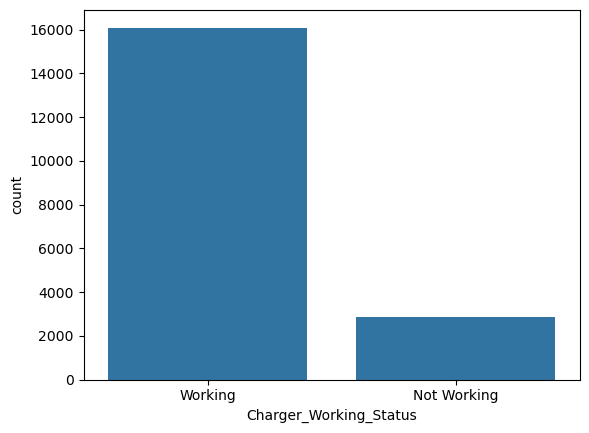

In [16]:
sns.countplot(data=df,x=df['Charger_Working_Status'])

## Bivariate Analysis

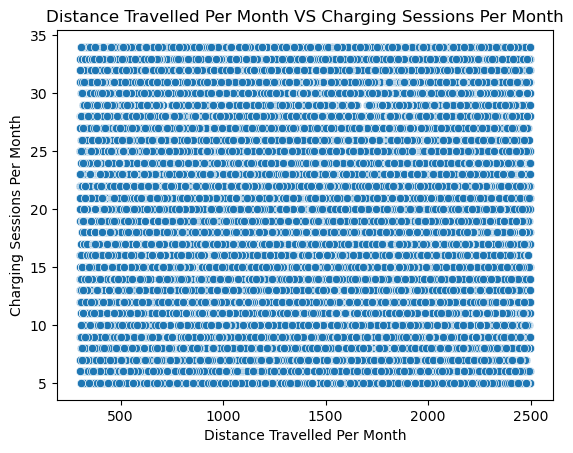

In [17]:
sns.scatterplot(x='Distance_Travelled_Per_Month',
                y='Charging_Sessions_Per_Month',
                data=df)
plt.title('Distance Travelled Per Month VS Charging Sessions Per Month')
plt.xlabel('Distance Travelled Per Month')
plt.ylabel('Charging Sessions Per Month')
plt.show()

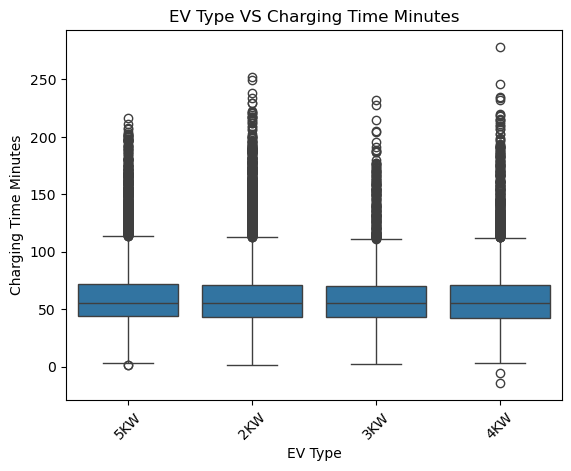

In [18]:
sns.boxplot(x='EV_Type', y='Charging_Time_Minutes', data=df)
plt.title('EV Type VS Charging Time Minutes')
plt.xlabel('EV Type')
plt.ylabel('Charging Time Minutes')
plt.xticks(rotation=45)
plt.show()

<Axes: xlabel='Income_Level', ylabel='count'>

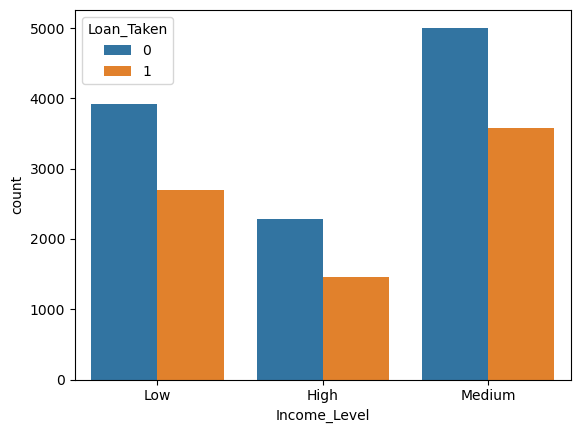

In [19]:
sns.countplot(data=df,x='Income_Level',hue='Loan_Taken')

In [20]:
pd.crosstab(df['Loan_Taken'],df['High_Default_Risk'])

High_Default_Risk,0,1
Loan_Taken,,
0,7763,3448
1,2771,4964


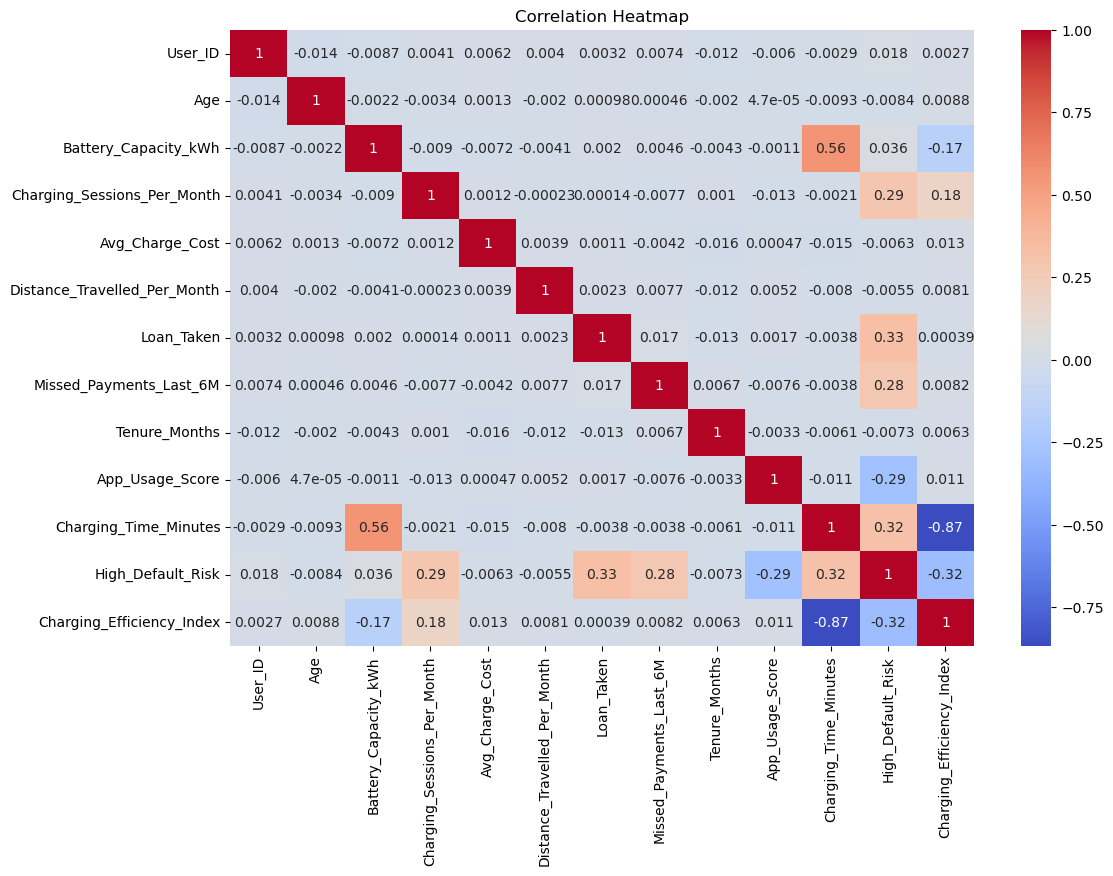

In [21]:
import seaborn as sns

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [24]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 18946 entries, 0 to 18945
Data columns (total 16 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Age                           18946 non-null  int64  
 1   City_Tier                     18946 non-null  object 
 2   EV_Type                       18946 non-null  object 
 3   Battery_Capacity_kWh          18946 non-null  float64
 4   Charging_Sessions_Per_Month   18946 non-null  int64  
 5   Avg_Charge_Cost               18946 non-null  float64
 6   Distance_Travelled_Per_Month  18946 non-null  int64  
 7   Income_Level                  18946 non-null  object 
 8   Loan_Taken                    18946 non-null  int64  
 9   Missed_Payments_Last_6M       18946 non-null  int64  
 10  Tenure_Months                 18946 non-null  int64  
 11  Charging_Location_Type        18946 non-null  object 
 12  App_Usage_Score               18946 non-null  int64  
 13  Charger_Work

In [25]:
X

,Age,City_Tier,EV_Type,Battery_Capacity_kWh,Charging_Sessions_Per_Month,Avg_Charge_Cost,Distance_Travelled_Per_Month,Income_Level,Loan_Taken,Missed_Payments_Last_6M,Tenure_Months,Charging_Location_Type,App_Usage_Score,Charger_Working_Status,Charging_Time_Minutes,Charging_Efficiency_Index
0,59,Tier3,5KW,40.7,19,325.10,1702,Low,0,2,1,Public,1,Working,58.5,100.00
1,49,Tier5,5KW,31.7,9,439.97,2377,High,0,0,1,Highway,7,Working,47.0,96.36
2,35,Tier5,5KW,36.8,24,309.80,1905,Low,0,5,6,Highway,4,Working,53.5,100.00
3,63,Tier5,2KW,38.5,32,353.90,2074,Medium,0,1,31,Highway,1,Not Working,112.0,57.96
4,28,Tier1,5KW,33.2,8,597.43,1212,Medium,0,2,24,Private,6,Working,58.0,84.56
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18941,54,Tier5,2KW,38.0,23,420.80,938,High,0,0,16,Highway,8,Working,58.0,100.00
18942,47,Tier3,5KW,28.6,29,555.51,1289,High,1,1,28,Highway,1,Working,39.8,100.00
18943,59,Tier2,5KW,28.6,17,500.97,577,Medium,0,5,15,Private,3,Working,34.3,100.00
18944,64,Tier2,4KW,42.3,30,417.63,2255,Low,0,1,18,Highway,2,Working,65.3,100.00


## Data Preprocessing

### Splitting the Data

In [23]:
X=df.drop(['High_Default_Risk','User_ID'],axis=1)
y=df['High_Default_Risk']

### Column Types

In [32]:
num_cols=X.select_dtypes(include=['int','float']).columns
cat_columns=X.select_dtypes(include='object').columns

print(num_cols)
print()
print(cat_cols)


Index(['Age', 'Battery_Capacity_kWh', 'Charging_Sessions_Per_Month',
       'Avg_Charge_Cost', 'Distance_Travelled_Per_Month', 'Loan_Taken',
       'Missed_Payments_Last_6M', 'Tenure_Months', 'App_Usage_Score',
       'Charging_Time_Minutes', 'Charging_Efficiency_Index'],
      dtype='str')

Index(['City_Tier', 'EV_Type', 'Income_Level', 'Charging_Location_Type',
       'Charger_Working_Status'],
      dtype='str')


### Train-Test-Split

In [33]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(15156, 16)
(3790, 16)
(15156,)
(3790,)


In [34]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler,OrdinalEncoder,OneHotEncoder
from category_encoders import BinaryEncoder
from sklearn.feature_selection import SelectKBest,mutual_info_classif

In [35]:
num_pipeline=Pipeline([
    ('Scaling_used',StandardScaler()),
    ('feature_selection',SelectKBest(score_func=mutual_info_classif,k='all'))
])

In [38]:
Ord_pipeline = Pipeline([
    ('ordinal_encoding', OrdinalEncoder(categories=[
        ['High','Medium','Low'],
        ['Tier1','Tier2','Tier3','Tier4','Tier5']
    ], handle_unknown='use_encoded_value', unknown_value=-1))
])

In [39]:
Ohe_pipeline = Pipeline([
    ('onehot_encoding', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

## Column Transformer

In [41]:
from sklearn.compose import ColumnTransformer

transformer = ColumnTransformer(transformers=[
    ('num', num_pipeline,num_cols),
    ('ord', Ord_pipeline, ['Income_Level','City_Tier']),
    ('ohe', Ohe_pipeline, ['EV_Type','Charging_Location_Type','Charger_Working_Status'])
])

### Intializing all the Algorithms

In [42]:
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

# Bagging and Boostig Algorithms 

from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import GradientBoostingClassifier
import xgboost as xgb

# Evaluation Metrics
from sklearn.metrics import accuracy_score


In [44]:
gnb_model=GaussianNB()
knn_model=KNeighborsClassifier()
dt_model=DecisionTreeClassifier(criterion='entropy', max_depth=2)
RF_model=RandomForestClassifier()
lr_model=LogisticRegression()
bc_model= BaggingClassifier(estimator =lr_model,n_estimators=20)
gb_model=GradientBoostingClassifier(n_estimators=50,learning_rate=1.0,max_depth=3,random_state=42)
xgb_model = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    max_depth=4,
    learning_rate=0.1,
    n_estimators=100
)


In [54]:
gnb_pipeline = Pipeline([
    ('preprocessing', transformer),
    ('model', gnb_model)
])

knn_pipeline = Pipeline([
    ('preprocessing', transformer),
    ('model', knn_model)
])

dt_pipeline=Pipeline([
    ('preprocessing', transformer),
    ('model', dt_model) ])

RF_pipeline=Pipeline([
    ('preprocessing', transformer),
    ('model', RF_model) ])

lr_pipeline=Pipeline([
    ('preprocessing', transformer),
    ('model', lr_model) ])

bc_pipeline=Pipeline([
    ('preprocessing', transformer),
    ('model', bc_model) ])

gb_pipeline=Pipeline([
    ('preprocessing', transformer),
    ('model',gb_model)])

xgb_pipeline=Pipeline([
    ('preprocessing', transformer),
    ('model',xgb_model)])

In [55]:
knn_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('ord', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transform

In [56]:
gnb_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('ord', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transform

In [57]:
dt_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('ord', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transform

In [58]:
lr_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('ord', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transform

In [59]:
RF_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('ord', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transform

In [60]:
bc_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('ord', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transform

In [61]:
gb_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('ord', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transform

In [62]:
xgb_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('ord', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transform

### Model Evaluation

In [71]:
gnb_pred = gnb_pipeline.predict(X_test)
knn_pred = knn_pipeline.predict(X_test)
dt_pred = dt_pipeline.predict(X_test)
lr_pred = lr_pipeline.predict(X_test)

# Ensemble Techniques
rf_pred = RF_pipeline.predict(X_test)
bc_pred = bc_pipeline.predict(X_test)
gb_pred = gb_pipeline.predict(X_test)
xgb_pred = xgb_pipeline.predict(X_test)

In [72]:
gnb_train_pred = gnb_pipeline.predict(X_train)
knn_train_pred = knn_pipeline.predict(X_train)
dt_train_pred = dt_pipeline.predict(X_train)
lr_train_pred = lr_pipeline.predict(X_train)

# Ensemble Tecniques
rf_train_pred = RF_pipeline.predict(X_train)
bc_train_pred = bc_pipeline.predict(X_train)
gb_train_pred = gb_pipeline.predict(X_train)
xgb_train_pred = xgb_pipeline.predict(X_train)

In [73]:
# Test accuracy
gnb_test_acc = accuracy_score(y_test, gnb_pred)
knn_test_acc = accuracy_score(y_test, knn_pred)
dt_test_acc=accuracy_score(y_test,dt_pred)
lr_test_acc=accuracy_score(y_test,lr_pred)

rf_test_acc=accuracy_score(y_test,rf_pred)
bc_test_acc=accuracy_score(y_test,bc_pred)
gb_test_acc=accuracy_score(y_test,gb_pred)
xgb_test_acc=accuracy_score(y_test,xgb_pred)


# Train accuracy
gnb_train_acc = accuracy_score(y_train, gnb_train_pred)
knn_train_acc = accuracy_score(y_train, knn_train_pred)
dt_train_acc=accuracy_score(y_train, dt_train_pred)
lr_train_acc=accuracy_score(y_train,lr_train_pred)

rf_train_acc=accuracy_score(y_train,rf_train_pred)
bc_train_acc=accuracy_score(y_train,bc_train_pred)
gb_train_acc=accuracy_score(y_train,gb_train_pred)
xgb_train_acc=accuracy_score(y_train,xgb_train_pred)

In [74]:
print("GaussianNB Train:", gnb_train_acc)
print("GaussianNB Test:", gnb_test_acc)
print()

print("KNN Train:", knn_train_acc)
print("KNN Test:", knn_test_acc)
print()

print('Decison Tree Train :',dt_train_acc)
print('Decison Tree Test :',dt_test_acc)
print()

print('Logistic Regression Train :',lr_train_acc)
print('Logistic Regression Test :',lr_test_acc)
print()

print('Random Forest Train :',rf_train_acc)
print('Random Forest Test :',rf_test_acc)
print()

print('Bagging Classifier Train :',bc_train_acc)
print('Bagging Classifier Test :',bc_test_acc)
print()

print('Gradiant Boosting Train :',gb_train_acc)
print('Gradiant Boosting Test :',gb_test_acc)
print()
print('XGB Boosting Train :',xgb_train_acc)
print('XGB Boosting Test :',xgb_test_acc)


GaussianNB Train: 0.6944444444444444
GaussianNB Test: 0.6915567282321899

KNN Train: 0.9358669833729216
KNN Test: 0.8828496042216358

Decison Tree Train : 0.7340987067827923
Decison Tree Test : 0.729023746701847

Logistic Regression Train : 0.8935075217735551
Logistic Regression Test : 0.89155672823219

Random Forest Train : 1.0
Random Forest Test : 0.9984168865435357

Bagging Classifier Train : 0.893573502243336
Bagging Classifier Test : 0.8918205804749341

Gradiant Boosting Train : 1.0
Gradiant Boosting Test : 1.0

XGB Boosting Train : 0.9994721562417525
XGB Boosting Test : 0.9989445910290238


In [77]:
import pickle
from sklearn.metrics import accuracy_score

# Store models in dictionary
models = {
    "GaussianNB": gnb_pipeline,
    "KNN": knn_pipeline,
    "Decision Tree": dt_pipeline,
    "Logistic Regression": lr_pipeline,
    "Random Forest": RF_pipeline,
    "Bagging": bc_pipeline,
    "Gradient Boosting": gb_pipeline,
    "XGBoost": xgb_pipeline
}

for name, model in models.items():
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    
    print(f"{name} Accuracy: {acc}")
    
    if acc > best_score:
        best_score = acc
        best_model = model
        best_model_name = name

# Save best model
with open("best_model.pkl", "wb") as f:
    pickle.dump(best_model, f)

print(f"\nBest Model: {best_model_name} with accuracy: {best_score}")
print("Best model saved as best_model.pkl")

GaussianNB Accuracy: 0.6915567282321899
KNN Accuracy: 0.8828496042216358
Decision Tree Accuracy: 0.729023746701847
Logistic Regression Accuracy: 0.89155672823219
Random Forest Accuracy: 0.9984168865435357
Bagging Accuracy: 0.8918205804749341
Gradient Boosting Accuracy: 1.0
XGBoost Accuracy: 0.9989445910290238

Best Model: Gradient Boosting with accuracy: 1.0
Best model saved as best_model.pkl
